<a href="https://colab.research.google.com/github/Ragul2526/opencv-image-filter-studio/blob/main/image_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python-headless -q
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output


Saving nature.jpeg to nature.jpeg
Image loaded:nature.jpeg-(148, 212, 3)


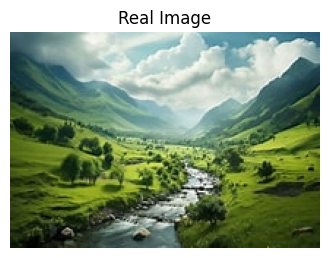

In [2]:
upload =  files.upload()
filename = list(upload.keys())[0]
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f"Image loaded:{filename}-{img.shape}")
plt.figure(figsize=(4,4))
plt. imshow(img)
plt.title("Real Image")
plt.axis("off")
plt.show()

In [8]:
def grayscale(img):
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  grayscaled = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
  return gray

def blur(img):

  return cv2.GaussianBlur(img, (15, 15), 0)

def sharpen(img):
  kernel = np.array([[0, -1, 0],
                     [-1, 5, -1],
                     [0, -1, 0]])
  return cv2.filter2D(img, -1, kernel)

def canny_edge(img):
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  edge = cv2.Canny(gray, 100, 200)

  return cv2.cvtColor(edge, cv2.COLOR_GRAY2RGB)

def sobel_edge(img):
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
  sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
  sobel = np.sqrt(sobelx ** 2 + sobely ** 2)
  sobel = np.uint8(sobel / sobel.max() * 255)
  sobel = cv2.cvtColor(sobel, cv2.COLOR_GRAY2RGB)
  return sobel

def cartoon(img):
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  blur = cv2.medianBlur(gray, 5)
  edges = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 9, 9)
  color = cv2.bilateralFilter(img, 9, 300, 300)
  edge_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
  cartoon = cv2.bitwise_and(edge_rgb, color, mask=edges)
  return cartoon

def pencil_sketch(img):
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  invert = cv2.bitwise_not(gray)
  blur = cv2.GaussianBlur(invert, (21, 21),0)
  sketch = cv2.divide(gray, 255-blur, scale=256)
  return cv2.cvtColor(sketch, cv2.COLOR_GRAY2RGB)

def emboss(img):
  kernel = np.array([[-2, -1, 0],
                     [-1, 1, 1],
                     [0, 1, 2]])
  embossed =  cv2.filter2D(img, -1, kernel) + 128
  return np.clip(embossed, 0, 255).astype(np.uint8)


def sepia(img):
  kernel = np.array([[0.272, 0.534, 0.131],
                       [0.349, 0.686, 0.168],
                       [0.393, 0.769, 0.189]])
  sepia_img = cv2.transform(img, kernel)
  return np.clip(sepia_img, 0, 255).astype(np.uint8)

def invert(img):

  return cv2.bitwise_not(img)

def warm_tone(img):
  warm = img.copy().astype(np.float32)
  warm[:, :, 0] = np.clip(warm[:, :, 0] * 1.2, 0, 255)  # boost red
  warm[:, :, 1] = np.clip(warm[:, :, 1] * 1.1, 0, 255)  # boost green
  warm[:, :, 2] = np.clip(warm[:, :, 2] * 0.8, 0, 255)  # reduce blue
  return warm.astype(np.uint8)

def cool_tone(img):
  cool = img.copy().astype(np.float32)
  cool[:, :, 0] = np.clip(cool[:, :, 0] * 0.8, 0, 255)
  cool[:, :, 1] = np.clip(cool[:, :, 1] * 9, 0, 255)
  cool[:, :, 2] = np.clip(cool[:, :, 2] * 1.3, 0, 255)
  return cool.astype(np.uint8)

FILTERS = {
    "Grayscale":      grayscale,
    "Blur":           blur,
    "Sharpen":        sharpen,
    "Canny Edge":     canny_edge,
    "Sobel Edge":     sobel_edge,
    "Cartoonify":     cartoon,
    "Pencil Sketch":  pencil_sketch,
    "Emboss":         emboss,
    "Sepia":          sepia,
    "Invert":         invert,
    "Warm Tone":      warm_tone,
    "Cool Tone":      cool_tone,
}

print(f"{len(FILTERS)} filters loaded!")


12 filters loaded!


In [12]:
upload =  files.upload()
filename = list(upload.keys())[0]
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
dropdown = widgets.Dropdown(
    options = list(FILTERS.keys()),
    value = "Grayscale",
    description = "Filter:",
    style = {"description_width": "initial"}
)
button = widgets.Button(description = "Apply",
                        button_style = "primary",
                        layout = widgets.Layout(width = "150px"))
download_button = widgets.Button(
    description = "Download",
    button_style = "success",
    layout = widgets.Layout(width = "150px")
)

output = widgets.Output()
def apply_filter(b):
    with output:
        clear_output(wait=True)
        selected = dropdown.value
        filtered = FILTERS[selected](img)
        if len(filtered.shape) == 2:
          filtered = cv2.cvtColor(filtered, cv2.COLOR_GRAY2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(img)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(filtered)
        axes[1].set_title(selected)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

        # save filtered image
        result_bgr = cv2.cvtColor(filtered, cv2.COLOR_RGB2BGR)
        cv2.imwrite("filtered_result.jpg", result_bgr)
def download_result(b):
  files.download("filtered_result.jpg")
button.on_click(apply_filter)
download_button.on_click(download_result)

display(widgets.VBox([
   widgets.HBox([dropdown, button, download_button]),
  output
]))


Saving OIP.jpeg to OIP.jpeg
